# Peak-Aware Learning Design — Phase 3 (Read-Only)

**Experiment 4 in the Module 1 research sequence.** Present the locked Peak-Aware Hybrid **design** (no training): fairness contract, timestep-weighted MSE, λ = 5, and rejected alternatives.

> **Scope:** Read-only view of `experiments/peak_aware_design_2026-07-14/phase3_design.json`.  
> Design-only phase — no model training, no baseline modification.  
> Docs: `docs/peak-aware-hybrid/phase-03-learning-design.md`.

## Research question

Given the locked P90 peak definition, **how** should Peak-Aware learning change the Hybrid GRU objective — and with what peak weight λ?

## Kernel

Use `tf_metal_env` / `FYP_Long_Term`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path("..").resolve()
DESIGN_DIR = REPO_ROOT / "experiments" / "peak_aware_design_2026-07-14"
DESIGN_JSON = DESIGN_DIR / "phase3_design.json"
DESIGN_MD = DESIGN_DIR / "phase3_design.md"

if not DESIGN_JSON.exists():
    raise FileNotFoundError(f"Missing locked design: {DESIGN_JSON}")

with open(DESIGN_JSON) as handle:
    design = json.load(handle)

locked = design["locked_design"]
lam_info = design["lambda_selection"]
fair = design["fairness_contract"]

print("Design dir :", DESIGN_DIR.relative_to(REPO_ROOT))
print("Status     :", design["status"], "| design_only =", design["design_only"])
print("Locked date:", design["locked_date"])
print("Mechanism  :", locked["mechanism"])
print("Lambda     :", locked["peak_weight_lambda"])

Design dir : experiments/peak_aware_design_2026-07-14
Status     : complete | design_only = True
Locked date: 2026-07-14
Mechanism  : timestep_weighted_mse
Lambda     : 5


## 1. Fairness contract — one experimental variable

Control = frozen Hybrid baseline. Treatment = Peak-Aware Hybrid. **Only** the GRU training loss changes.

In [2]:
print("Control model :", fair["control_model"])
print("Control dir   :", fair["control_reference_dir"])
print("Intentional difference:", fair["intentional_difference"])
print("\nIdentical components (held fixed)")
display(pd.DataFrame({"component": fair["identical_components"]}))

Control model : hybrid_prophet_gru_v1
Control dir   : experiments/baseline_reference_2026-07-14
Intentional difference: timestep_weighted_mse_on_y_train

Identical components (held fixed)


,component
0,preprocessing
1,train_val_split
2,prophet_config
3,residual_computation
4,res_mean_res_std
5,sequence_construction
6,gru_architecture
7,optimizer_epochs_batch_shuffle
8,early_stopping_criterion
9,inference_pipeline


## 2. Locked mechanism — timestep-weighted MSE

For each forecast-horizon step $t$:

$$
w_t = \begin{cases} \lambda & \text{if peak under P90} \\ 1 & \text{otherwise} \end{cases}
$$

Loss uses weighted squared error on residual targets. Early stopping stays on **unweighted** `val_loss`.

In [3]:
mech_rows = [
    {"item": "mechanism", "value": locked["mechanism"]},
    {"item": "peak rule", "value": locked["peak_definition"]["rule"]},
    {"item": "weighting granularity", "value": locked["weighting_granularity"]},
    {"item": "weight scope", "value": locked["weight_scope"]},
    {"item": "peak weight λ", "value": locked["peak_weight_lambda"]},
    {"item": "non-peak weight", "value": locked["non_peak_weight"]},
    {"item": "input window", "value": locked["input_window"]},
    {"item": "forecast horizon", "value": locked["forecast_horizon"]},
    {"item": "early stopping monitor", "value": locked["early_stopping"]["monitor"]},
    {"item": "early stopping weighted?", "value": locked["early_stopping"]["weighted"]},
    {"item": "inference", "value": locked["inference"]},
    {"item": "evaluation", "value": locked["evaluation"]},
]
print("Table — Locked design summary")
display(pd.DataFrame(mech_rows))

print("\nRejected mechanisms")
display(pd.DataFrame({"rejected": design["rejected_mechanisms"]}))

Table — Locked design summary


,item,value
0,mechanism,timestep_weighted_mse
1,peak rule,cpu_real >= P90(container_train)
2,weighting granularity,timestep
3,weight scope,forecast_horizon_targets_only
4,peak weight λ,5
5,non-peak weight,1
6,input window,96
7,forecast horizon,96
8,early stopping monitor,val_loss
9,early stopping weighted?,False



Rejected mechanisms


,rejected
0,sequence_weighted_mse
1,oversampling_peak_sequences
2,focal_loss
3,weighted_huber_loss
4,quantile_loss
5,prophet_side_peak_awareness
6,architecture_changes
7,class_balanced_sampling


## 3. λ decision — analytical balance (not a validation sweep)

With train peak fraction $p \approx 0.174$ at P90:

$$
\text{peak\_loss\_share} = \frac{p\lambda}{p\lambda + (1-p)}
$$

Candidates considered: 3, 5, 10. Locked: **λ = 5** (~51% of weighted loss from peaks).

Table — λ candidates (analytical)


,lambda,peak_loss_share_%,verdict
0,3,38.72,Too mild for a clear peak-aware contribution
1,5,51.30,LOCKED — balanced (~50% peak loss share)
2,10,67.81,Too aggressive — risks non-peak degradation


Selection method : analytical_fixed_choice
Locked λ         : 5
Peak loss share @ λ=5: 51.3%
Rejected λ approaches: temporal_validation_tuning, large_hyperparameter_grid, per_container_lambda, adaptive_lambda


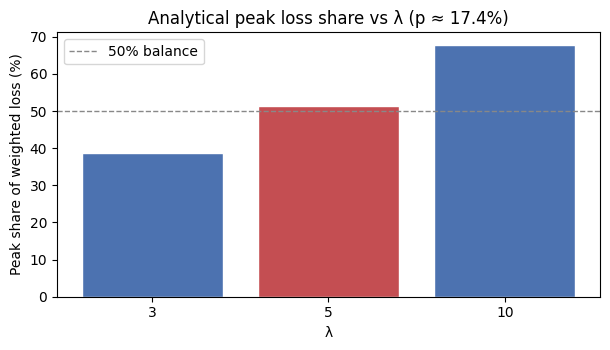


Table — Average sequence loss budget (unit error illustration)


,lambda,peak_contribution,non_peak_contribution,peak_share_%
0,3,48.78,79.74,37.96
1,5,81.30,79.74,50.48
2,10,162.60,79.74,67.10


In [4]:
p = 0.174  # Phase 2 train peak fraction at P90
candidates = lam_info["candidates_considered"]

rows = []
for lam in candidates:
    share = (p * lam) / (p * lam + (1 - p))
    rows.append({
        "lambda": lam,
        "peak_loss_share_%": 100 * share,
        "verdict": {
            3: "Too mild for a clear peak-aware contribution",
            5: "LOCKED — balanced (~50% peak loss share)",
            10: "Too aggressive — risks non-peak degradation",
        }.get(lam, ""),
    })

lam_table = pd.DataFrame(rows)
print("Table — λ candidates (analytical)")
display(lam_table.round(2))

print("Selection method :", lam_info["selection_method"])
print("Locked λ         :", lam_info["locked_value"])
print("Peak loss share @ λ=5:", f"{100 * lam_info['analytical_peak_loss_share_at_lambda_5']:.1f}%")
print("Rejected λ approaches:", ", ".join(lam_info["rejected_approaches"]))

fig, ax = plt.subplots(figsize=(6.2, 3.6))
colors = ["#4C72B0" if lam != 5 else "#C44E52" for lam in lam_table["lambda"]]
ax.bar(lam_table["lambda"].astype(str), lam_table["peak_loss_share_%"], color=colors, edgecolor="white")
ax.axhline(50, color="#888888", linestyle="--", linewidth=1, label="50% balance")
ax.set_xlabel("λ")
ax.set_ylabel("Peak share of weighted loss (%)")
ax.set_title("Analytical peak loss share vs λ (p ≈ 17.4%)")
ax.legend()
fig.tight_layout()
plt.show()

# Per-sequence illustration (mean 16.26 peak steps of 96)
k, n = 16.26, 96
seq_rows = []
for lam in candidates:
    peak_c = k * lam
    non_c = n - k
    seq_rows.append({
        "lambda": lam,
        "peak_contribution": peak_c,
        "non_peak_contribution": non_c,
        "peak_share_%": 100 * peak_c / (peak_c + non_c),
    })
print("\nTable — Average sequence loss budget (unit error illustration)")
display(pd.DataFrame(seq_rows).round(2))

## 4. Training protocol & Phase 4 plan

In [5]:
proto = design["training_protocol_summary"]
hp = locked["training_hyperparameters"]

print("Training protocol")
display(pd.DataFrame([{"item": k, "value": v} for k, v in proto.items()]))

print("\nHyperparameters (unchanged vs baseline except weighted loss)")
display(pd.DataFrame([{"item": k, "value": v} for k, v in hp.items()]))

print("\nPlanned Phase 4 modules")
display(pd.DataFrame({"new_file": design["phase_4_modules"]["new_files"]}))

print("\nPhase 5 evaluation preview")
display(pd.DataFrame([{"item": k, "value": v} for k, v in design["phase_5_evaluation_preview"].items()]))

Training protocol


,item,value
0,weight_tensor_shape,"(n_samples, 96)"
1,weights_on,y_train_only
2,validation_unweighted,True
3,threshold_artifact,peak/peak_thresholds.pkl
4,residual_stats_artifact,models/residual_stats.pkl



Hyperparameters (unchanged vs baseline except weighted loss)


,item,value
0,optimizer,adam
1,base_loss,mse
2,metrics,[mae]
3,epochs_max,100
4,batch_size,64
5,shuffle,False
6,random_seed,42
7,sequence_val_split,0.8



Planned Phase 4 modules


,new_file
0,utils/peak_config.py
1,utils/peak_detection.py
2,utils/hybrid_training_peak_aware.py
3,scripts/run_peak_aware_hybrid_experiment.py
4,scripts/verify_peak_aware_fairness.py



Phase 5 evaluation preview


,item,value
0,overall_metrics,"[day1_mae, day1_rmse, day1_mape]"
1,peak_subset_metrics,"[peak_mae, peak_rmse]"
2,non_peak_subset_metrics,"[non_peak_mae, non_peak_rmse]"
3,optional_stratification,"[stable, medium, spiky]"
4,evaluation_horizon,day1_96_steps_per_container
5,peak_label_rule,same_p90_train_fitted_thresholds


## 5. Key findings & results (viva summary)

Phase 3 has **design results**, not forecast metrics.

In [6]:
findings = pd.DataFrame([
    {
        "finding": "Single experimental variable",
        "result": "GRU loss: uniform MSE → timestep-weighted MSE",
    },
    {
        "finding": "Mechanism",
        "result": "Timestep-weighted MSE on forecast-horizon targets (P90 peaks)",
    },
    {
        "finding": "Why not sequence weighting",
        "result": "~96% of sequences contain ≥1 peak → nearly uniform up-weight",
    },
    {
        "finding": "Locked λ",
        "result": "λ = 5 (analytical; peaks ≈ 51% of weighted loss)",
    },
    {
        "finding": "λ candidates rejected",
        "result": "3 too mild; 10 too aggressive; no val-period λ tuning",
    },
    {
        "finding": "Early stopping",
        "result": "Unweighted val_loss (same as baseline)",
    },
    {
        "finding": "Inference / primary eval",
        "result": "Unchanged Hybrid pipelines",
    },
])

print("Table — Key findings (design lock)")
display(findings)

print("\nKnown limitations")
for item in design.get("known_limitations", []):
    print(f"  - {item}")

print("\n" + "=" * 72)
print("KEY FINDING")
print("=" * 72)
print(
    "Phase 3 locked Peak-Aware Hybrid as timestep-weighted MSE with λ = 5 on "
    "P90 peak horizon steps, holding every other Hybrid component identical to "
    "baseline_reference_2026-07-14. No model was trained here; implementation "
    "and Day-1 comparison happen in Phases 4–5."
)
print("=" * 72)

if DESIGN_MD.exists():
    print("\nAlso available:", DESIGN_MD.relative_to(REPO_ROOT))

Table — Key findings (design lock)


,finding,result
0,Single experimental variable,GRU loss: uniform MSE → timestep-weighted MSE
1,Mechanism,Timestep-weighted MSE on forecast-horizon targ...
2,Why not sequence weighting,~96% of sequences contain ≥1 peak → nearly uni...
3,Locked λ,λ = 5 (analytical; peaks ≈ 51% of weighted loss)
4,λ candidates rejected,3 too mild; 10 too aggressive; no val-period λ...
5,Early stopping,Unweighted val_loss (same as baseline)
6,Inference / primary eval,Unchanged Hybrid pipelines



Known limitations
  - Five near-idle containers have P90 threshold 0.0, inflating peak labels (~29% of train peak timesteps)
  - Validation peak rates exceed train rates under fixed thresholds
  - Spiky workload label partially reflects near-idle CV artefact
  - Lambda 5 chosen analytically, not empirically swept
  - Stochastic GRU training may vary slightly across hardware despite seed 42

KEY FINDING
Phase 3 locked Peak-Aware Hybrid as timestep-weighted MSE with λ = 5 on P90 peak horizon steps, holding every other Hybrid component identical to baseline_reference_2026-07-14. No model was trained here; implementation and Day-1 comparison happen in Phases 4–5.

Also available: experiments/peak_aware_design_2026-07-14/phase3_design.md


## 6. References

| Item | Path |
|------|------|
| Locked design JSON | `experiments/peak_aware_design_2026-07-14/phase3_design.json` |
| Design markdown | `experiments/peak_aware_design_2026-07-14/phase3_design.md` |
| Research log | `docs/peak-aware-hybrid/phase-03-learning-design.md` |
| Prior peak definition | `experiments/peak_exploration_2026-07-14/` + `notebooks/peak_exploration_analysis.ipynb` |
| Baseline control | `experiments/baseline_reference_2026-07-14/` |
| Next (implementation/eval notebook) | `notebooks/peak_aware_container_comparison.ipynb` |